In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Create outputs directory
os.makedirs("outputs", exist_ok=True)

In [5]:
df = pd.read_csv(r"C:\Users\User\OneDrive\New folder\python project\K-nearest-neighbors-From-Scratch\data\Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 400
Columns : 5


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.7 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [9]:
missing = df.isnull().sum()

missing

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


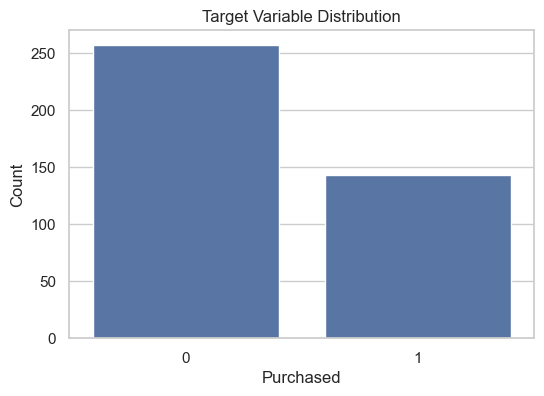

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Purchased")

plt.title("Target Variable Distribution")
plt.xlabel("Purchased")
plt.ylabel("Count")

plt.savefig("../outputs/target_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

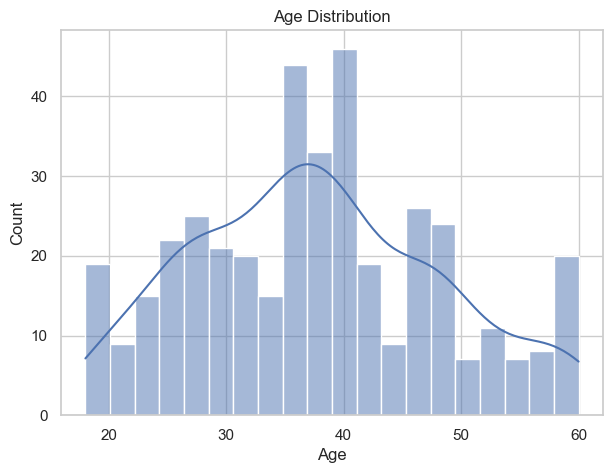

In [12]:
plt.figure(figsize=(7,5))

sns.histplot(df["Age"],bins=20,kde=True)

plt.title("Age Distribution")

plt.savefig("../outputs/age_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

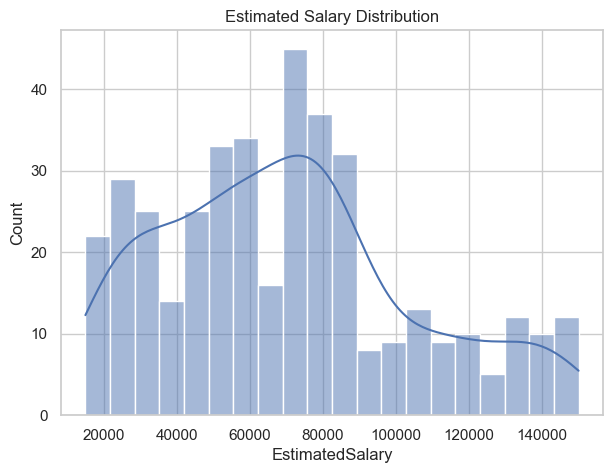

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(df["EstimatedSalary"],bins=20,kde=True)

plt.title("Estimated Salary Distribution")

plt.savefig("../outputs/salary_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

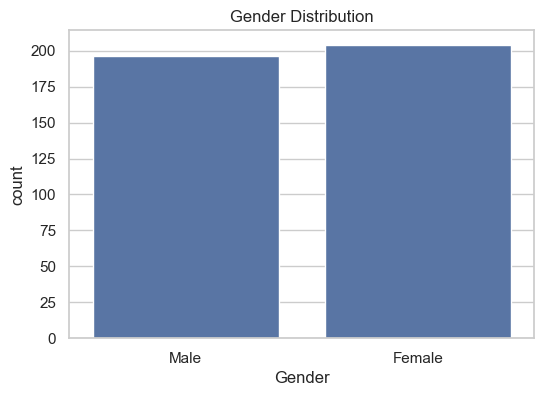

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Gender")

plt.title("Gender Distribution")

plt.savefig("../outputs/gender_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

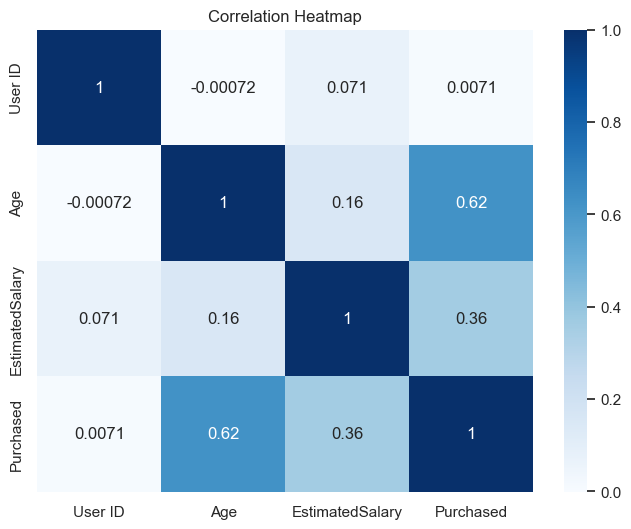

In [15]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.savefig("../outputs/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

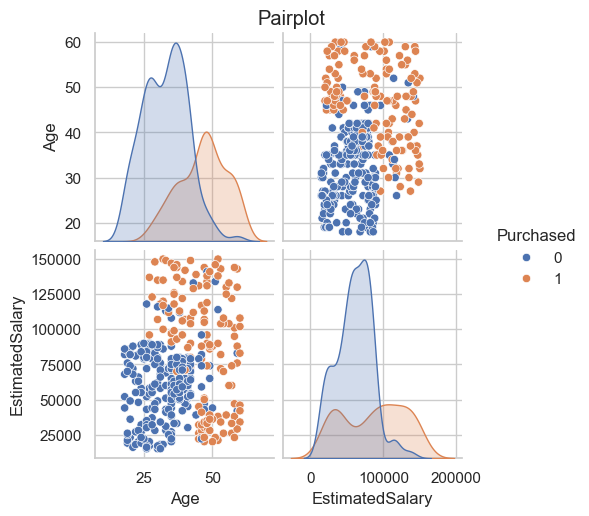

In [16]:
pair = sns.pairplot(
    df,
    hue="Purchased",
    vars=["Age","EstimatedSalary"]
)

pair.fig.suptitle("Pairplot", y=1.02)

pair.savefig("../outputs/pairplot.png")

plt.show()

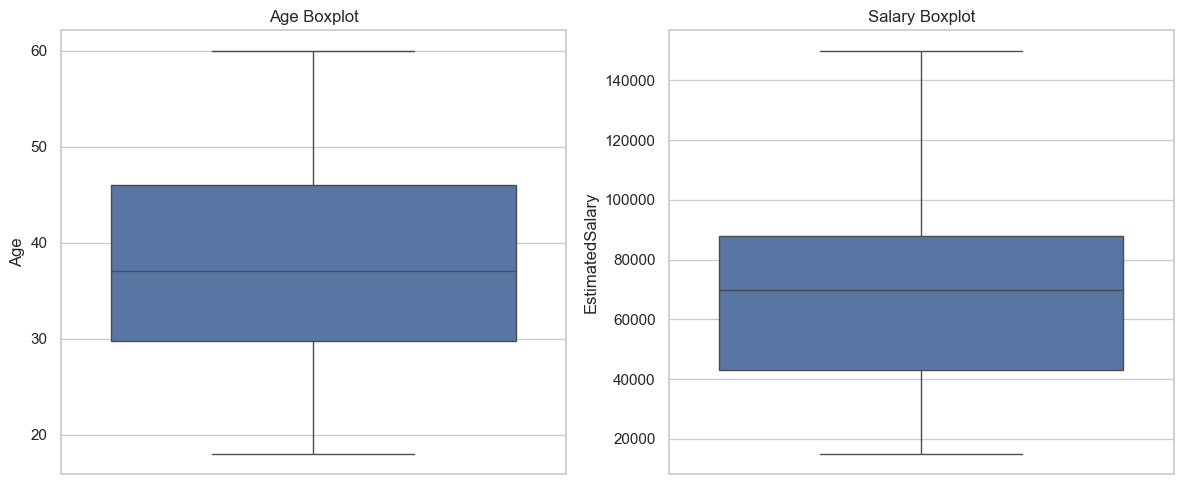

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.boxplot(y=df["Age"])

plt.title("Age Boxplot")

plt.subplot(1,2,2)

sns.boxplot(y=df["EstimatedSalary"])

plt.title("Salary Boxplot")

plt.tight_layout()

plt.savefig("../outputs/boxplots.png",
            dpi=300)

plt.show()

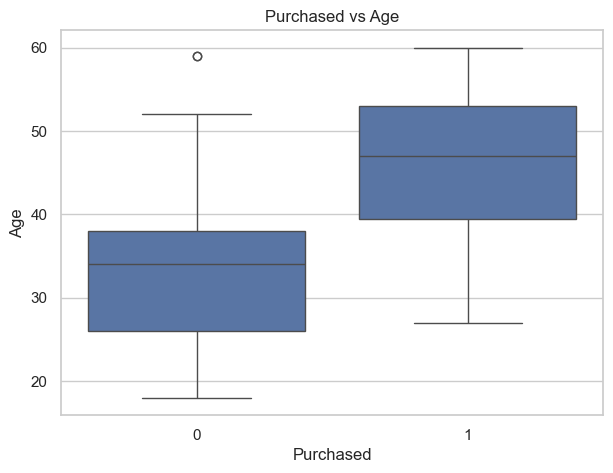

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Purchased",
    y="Age"
)

plt.title("Purchased vs Age")

plt.savefig("../outputs/purchased_age.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

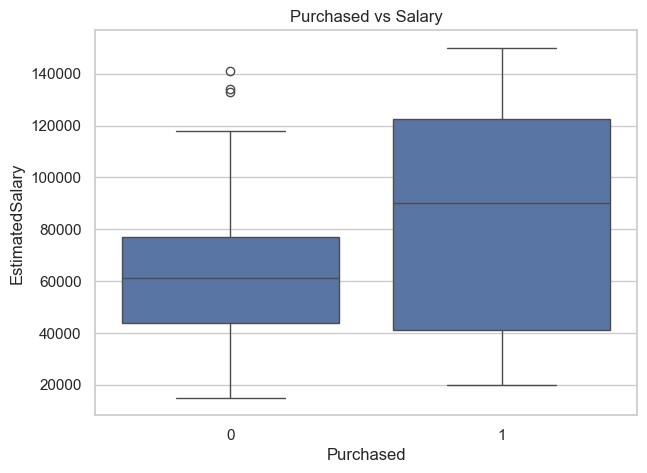

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Purchased",
    y="EstimatedSalary"
)

plt.title("Purchased vs Salary")

plt.savefig("../outputs/purchased_salary.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

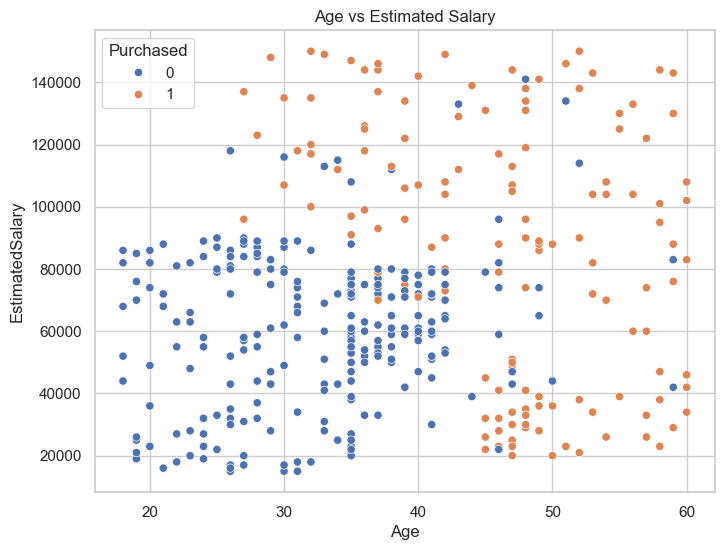

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="EstimatedSalary",
    hue="Purchased"
)

plt.title("Age vs Estimated Salary")

plt.savefig("../outputs/scatter_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()